## Debugging or Tracing using LangSmith

In [1]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages, BaseMessage
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_core.tools import tool
import os
from dotenv import load_dotenv

In [2]:
load_dotenv(override=True)

True

In [3]:
# 2. Set both LANGSMITH and LANGCHAIN environment variables
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
os.environ["LANGSMITH_TRACING"] = os.getenv("LANGSMITH_TRACING", "true")
os.environ["LANGSMITH_PROJECT"] = os.getenv("LANGSMITH_PROJECT", "TracingProject")
os.environ["LANGCHAIN_TRACING_V2"] = os.getenv("LANGCHAIN_TRACING_V2", "true")
os.environ["LANGCHAIN_PROJECT"] = os.getenv("LANGCHAIN_PROJECT", "TracingProject")
os.environ["LANGCHAIN_API_KEY"] = os.getenv("LANGSMITH_API_KEY")

In [4]:
## Intialize LLM
from langchain_groq import ChatGroq

llm= ChatGroq(model="qwen/qwen3.6-27b")

In [5]:
## Create state
class State(TypedDict):
  messages: Annotated[list[BaseMessage], add_messages]

In [6]:
## Graph with tool call

@tool
def add(a: float, b: float):
  """Add two number"""
  return a + b

tools = [add]
llm_with_tools = llm.bind_tools(tools)

In [7]:
## Node defnition
def call_llm_model(state: State):
  return {"messages": [llm_with_tools.invoke(state["messages"])]}


## Create Graph
builder = StateGraph(State)

## Add nodes
builder.add_node("chatbot", call_llm_model)

tool_node = ToolNode(tools=tools)
builder.add_node("tools", tool_node)

## Add Edges
builder.add_edge(START, "chatbot")
builder.add_conditional_edges(
  "chatbot",
  tools_condition
)
builder.add_edge("tools", "chatbot")


## Compile the graph
graph = builder.compile()

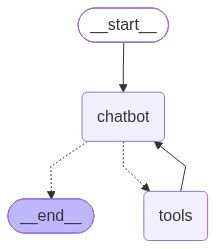

In [8]:
# Show graph
from IPython.display import Image, display
try:
  display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
  # This requires some extra dependencies and is optional
  pass

In [9]:
## Call the chatbot
response = graph.invoke({"messages": "what is 5 plus 8"})

In [11]:
response

{'messages': [HumanMessage(content='what is 5 plus 8', additional_kwargs={}, response_metadata={}, id='41e1083c-a88c-43ca-89d4-2d1e92d5a246'),
  AIMessage(content='', additional_kwargs={'reasoning_content': "Thinking Process:\n1.  Identify the user's request: Calculate the sum of 5 and 8.\n2.  Check available tools: `add` function takes two numbers `a` and `b` and returns their sum.\n3.  Determine tool usage: Call `add` with `a=5` and `b=8`.\n4.  Execute tool call.\n5.  Formulate response based on tool output.✅\n", 'tool_calls': [{'id': '4e113ggvf', 'function': {'arguments': '{"a":5,"b":8}', 'name': 'add'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 133, 'prompt_tokens': 283, 'total_tokens': 416, 'completion_time': 0.252522792, 'completion_tokens_details': {'reasoning_tokens': 96}, 'prompt_time': 0.019836438, 'prompt_tokens_details': None, 'queue_time': 0.044839996, 'total_time': 0.27235923}, 'model_name': 'qwen/qwen3.6-27b', 'system_fingerprint': 'f

In [12]:
## Call the chatbot
response = graph.invoke({"messages": "what is Machine Learning"})
print(response["messages"][-1].content)

**Machine Learning (ML)** is a branch of artificial intelligence (AI) that enables computers to learn from data and improve their performance over time without being explicitly programmed with fixed rules.

### 🔍 How It Works
Instead of writing step-by-step instructions, you feed data into an ML algorithm. The algorithm analyzes the data, identifies patterns, and builds a mathematical **model**. Once trained, this model can make predictions or decisions on new, unseen data.

### 📚 Main Types of Machine Learning
1. **Supervised Learning**: Learns from labeled data (input + correct output). Used for tasks like email spam detection, house price prediction, and image classification.
2. **Unsupervised Learning**: Finds hidden patterns or groupings in unlabeled data. Common uses include customer segmentation, recommendation engines, and anomaly detection.
3. **Reinforcement Learning**: Learns through trial and error by receiving rewards or penalties for actions. Used in game-playing AI, robo